In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [91]:
def compute_spectra(bins, v, ndft):
    sfdr = np.zeros(len(bins))
    hd3 = np.zeros(len(bins))
    spec_dbv_out = np.zeros((len(bins), ndft//2+1))
    for i in bins:
        y = v[i-1, :]
        y = y[:-1]
        relative_error = (y[-1]-y[-1-ndft])/y[-1]
        print(relative_error)
        y = y[-ndft:]
        spec = np.fft.rfft(y)
        spec_dbv = 20*np.log10(np.abs(spec)/(ndft/2))
        spec_dbv_out[i-1, :] = spec_dbv
        sfdr[i-1] = spec_dbv[i] - np.max(np.delete(spec_dbv, [0, i]))
        hd3[i-1] = spec_dbv[i] - spec_dbv[get_third_harmonic_bin(i, ndft)]
    return sfdr, hd3, spec_dbv_out

In [92]:
def get_third_harmonic_bin(i, ndft):
    """
    Finds the 3rd harmonic bin for a real-valued signal.
    i: fundamental bin index
    nfft: total number of FFT points
    """
    # Step 1: Wrap around the sampling frequency
    wrapped_bin = (3 * i) % ndft
    
    # Step 2: Fold back if it's above Nyquist
    if wrapped_bin > ndft // 2:
        harmonic_bin = ndft - wrapped_bin
    else:
        harmonic_bin = wrapped_bin
        
    return int(harmonic_bin)

In [93]:
df1 = pd.read_csv('./xschem/simulation/tb_boot_bottom_3.txt', sep='\\s+')
df1

,time,v(vi),v(vo)
0,1.900000e-09,0.657403,0.630902
1,3.900000e-09,0.715502,0.690221
2,5.900000e-09,0.768872,0.745925
3,7.900000e-09,0.815328,0.795668
4,9.900000e-09,0.852969,0.837419
...,...,...,...
535,6.390000e-08,0.675275,0.898018
536,6.590000e-08,0.495730,0.303686
537,6.790000e-08,0.732189,0.890066
538,6.990000e-08,0.441239,0.317158


In [94]:
# Parameters
fs = 500e6
ndft = 31
runs = 15
bins = np.arange(1, runs+1)

In [95]:
vi = np.reshape(df1['v(vi)'].values, [runs, len(df1)//runs])
vo = np.reshape(df1['v(vo)'].values, [runs, len(df1)//runs])

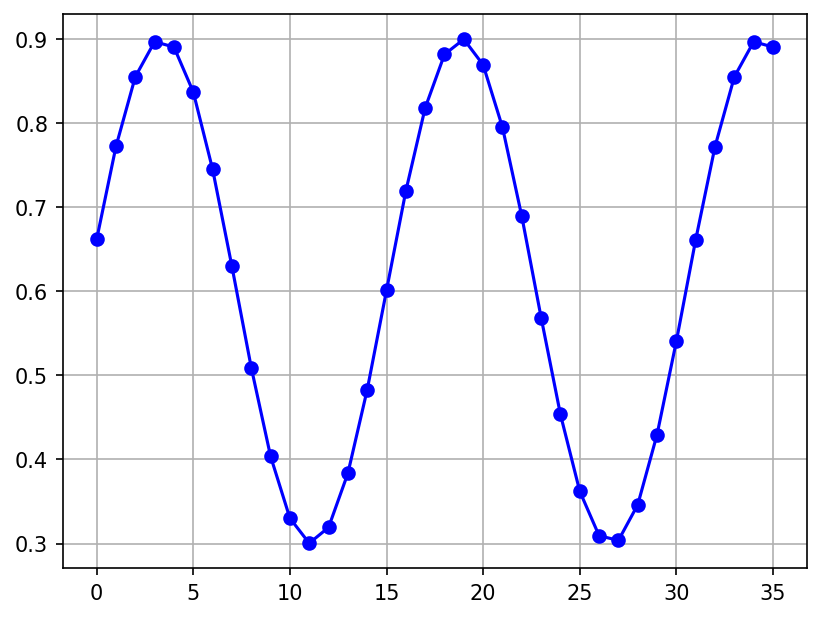

In [96]:
plt.plot(vo[1, :], "b-o")
plt.grid()
plt.show()

In [97]:
hd3_vi = compute_spectra(bins, vi, ndft)[1]
hd3_vo = compute_spectra(bins, vo, ndft)[1]

1.9623998025731274e-09
-2.667076982535209e-09
1.5456476024781037e-08
1.3750610731044149e-09
7.996939886179853e-07
-3.2697740117762437e-07
1.0481887897264073e-06
3.166503849718734e-07
-4.3191626068689057e-07
3.1139442521064788e-06
1.1139464034754423e-06
6.621498656896379e-07
-2.841645915738453e-06
1.2156172433915444e-06
1.3734053471385252e-07
2.901202048606825e-06
-8.101889266726409e-07
8.893091914426411e-07
1.140115631434441e-06
3.4291128451317223e-06
2.052839996030658e-07
-9.39239206286434e-07
6.238917004667093e-09
-1.723080171994955e-05
8.8896045595038e-06
-9.633086160387288e-07
-8.976515402585789e-07
-6.372745793870977e-06
3.872497889124005e-06
-2.0090921718053615e-06


In [98]:
# Analytical data
vov = 0.734
vm = 0.3
fs = 500e6
fin = bins*fs/ndft
c = 1.3e-12
cb = 400e-15
cp =  20e-15
fbw = 6.1e9
hd3_calc = -20*np.log10((1/2)*fin/fbw*(vm/vov)**2 *(cp/cb+0.2)**2)
print(fbw/1e6)

6100.0


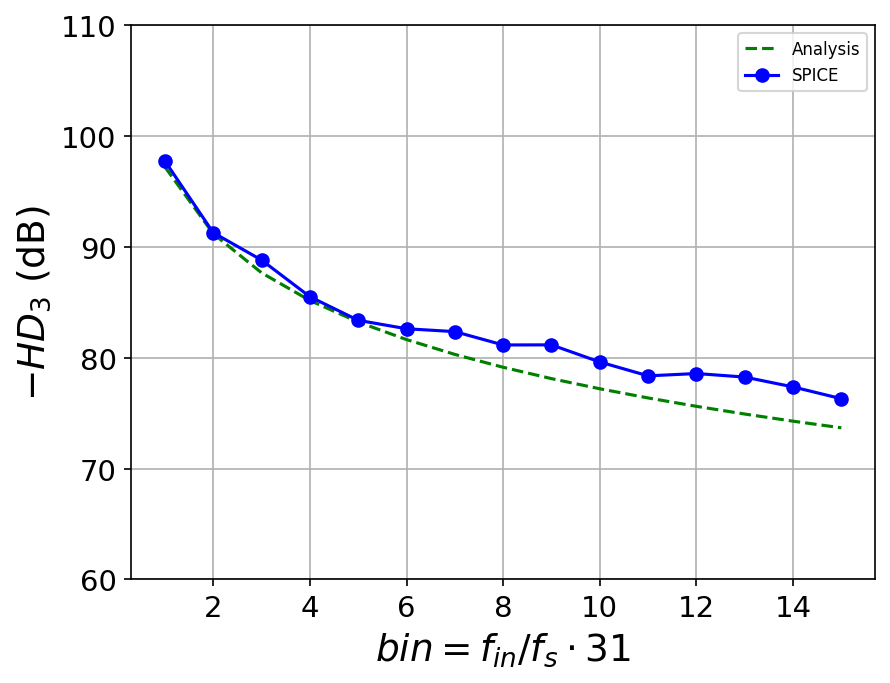

In [101]:
plt.rcParams['figure.dpi'] = 150
plt.plot(bins, hd3_calc, "g--", label='Analysis')
#plt.plot(bins, hd3_vi, "r--", label='vi hold')
plt.plot(bins, hd3_vo, "b-o", label='SPICE')
    
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("$-HD_3$ (dB)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(60, 110)
plt.grid(True)
plt.legend(fontsize=8)
plt.show()

2.901202048606825e-06
-8.101889266726409e-07
8.893091914426411e-07
1.140115631434441e-06
3.4291128451317223e-06
2.052839996030658e-07
-9.39239206286434e-07
6.238917004667093e-09
-1.723080171994955e-05
8.8896045595038e-06
-9.633086160387288e-07
-8.976515402585789e-07
-6.372745793870977e-06
3.872497889124005e-06
-2.0090921718053615e-06


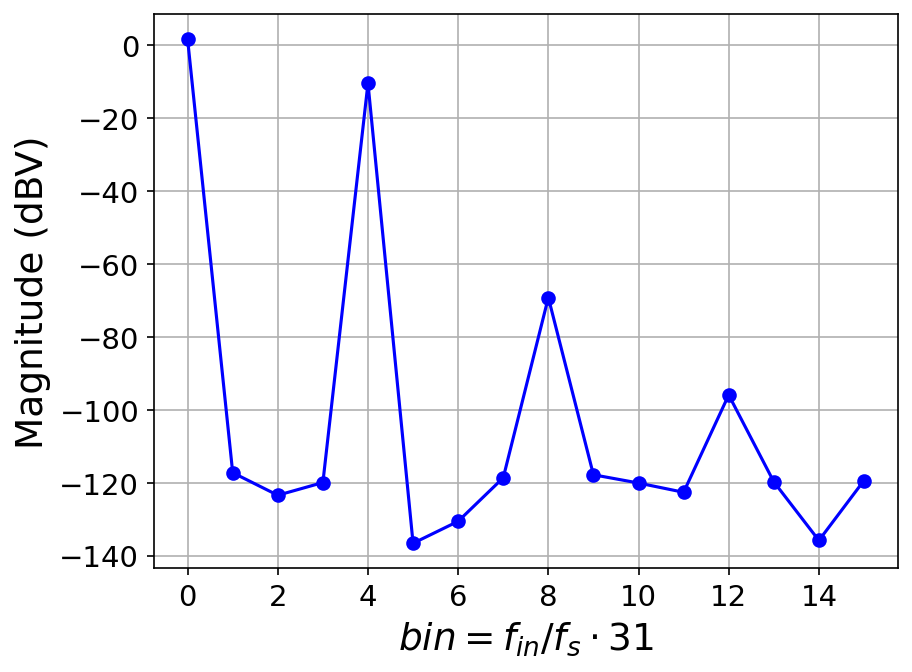

In [100]:
spec_dbv_out = compute_spectra(bins, vo, ndft)[2]

plt.plot(spec_dbv_out[3, :], "b-o")
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("Magnitude (dBV)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylim(25, 72)
plt.grid(True)
plt.show()
